# Stage–Discharge Relationship of the Waal River using MCMC
This notebook calibrates a stage–discharge relationship for the Waal River near Nijmegen using Markov Chain Monte Carlo (MCMC).
Daily discharge and water level observations are combined, and parameter uncertainty is explicitly quantified.

In [1]:
# Import necessary libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats 
from scipy.optimize import curve_fit
import arviz as az
import pymc as pm

## Loading Data

### 1. Discharge Data Processing

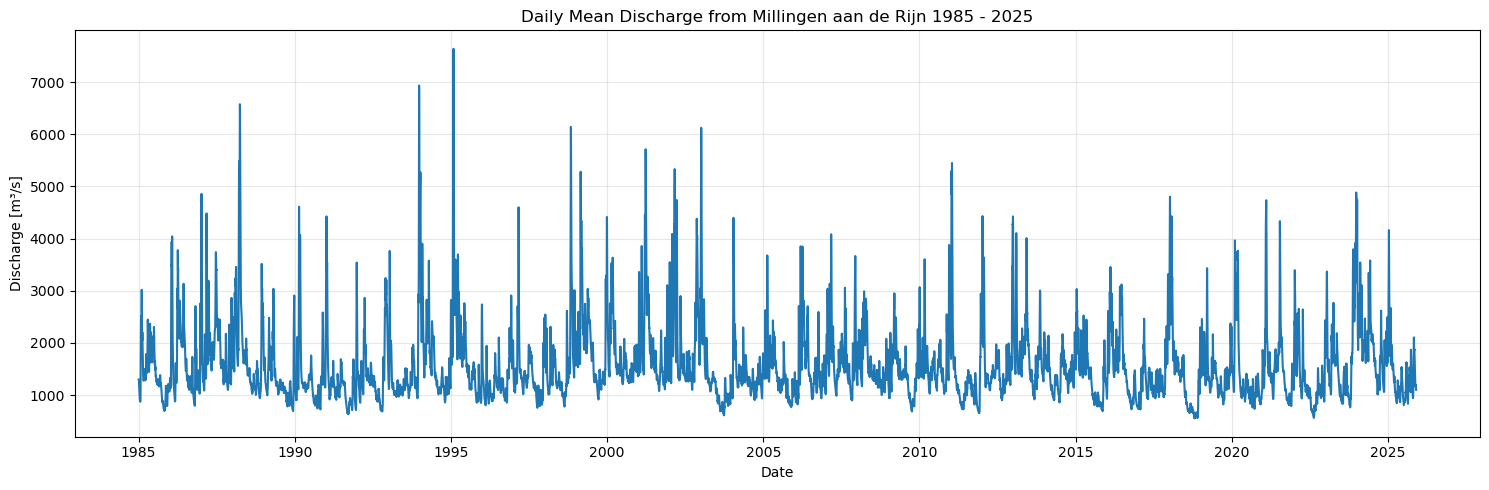

In [2]:
files = ['data/Mill1.csv', 'data/Mill2.csv', 'data/Mill3.csv', 'data/Mill4.csv']

data_frames = []

for file_name in files:
    df = pd.read_csv(file_name, sep=';', encoding="latin1")
    df["datum"] = pd.to_datetime(df["datum"], dayfirst=True)
    df["waarde"] = pd.to_numeric(df["waarde"].astype(str).str.replace(",", "."))
    df.loc[df["waarde"] > 1e5, "waarde"] = np.nan 
    df = df.dropna(subset=["datum", "waarde"]) 
    
    daily_mean = df.groupby("datum")["waarde"].mean()
    data_frames.append(daily_mean)


Q_series = pd.concat(data_frames).sort_index()
Q_series = Q_series.groupby(Q_series.index).mean() #removes overlapping dates

# Plotting
plt.figure(figsize=(15, 5))
plt.plot(Q_series.index, Q_series.values)
plt.xlabel("Date")
plt.ylabel("Discharge [m³/s]")
plt.title("Daily Mean Discharge from Millingen aan de Rijn 1985 - 2025")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Water Level Data Processing

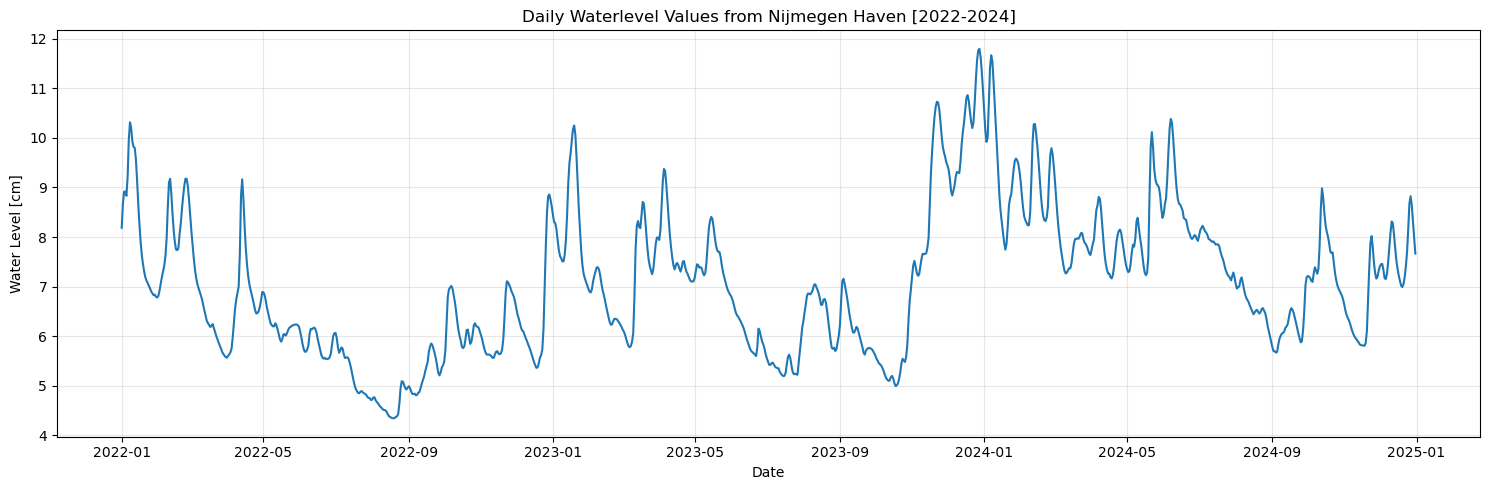

In [3]:
filename = 'data/nijmegen_haven_2022-2024.csv'

df_h = pd.read_csv(filename, sep=';', encoding="latin1")
df_h["datum"] = pd.to_datetime(df_h["WAARNEMINGDATUM"],dayfirst=True)
df_h["waarde"] = pd.to_numeric(df_h["NUMERIEKEWAARDE"].astype(str).str.replace(",", "."))
df_h.loc[df_h["waarde"] > 1e5, "waarde"] = np.nan 

df_h['waarde_meters'] = df_h['waarde'] / 100.0
df_h = df_h.dropna(subset=["datum", "waarde_meters"]) 
h_series = df_h.groupby("datum")["waarde_meters"].mean() # transform to daily mean 

# Plotting
plt.figure(figsize=(15, 5))
plt.plot(h_series.index, h_series.values)
plt.xlabel("Date")
plt.ylabel("Water Level [cm]")
plt.title(f"Daily Waterlevel Values from Nijmegen Haven [2022-2024]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Merging Discharge and Water Level Data

Total Combined Days: 1092


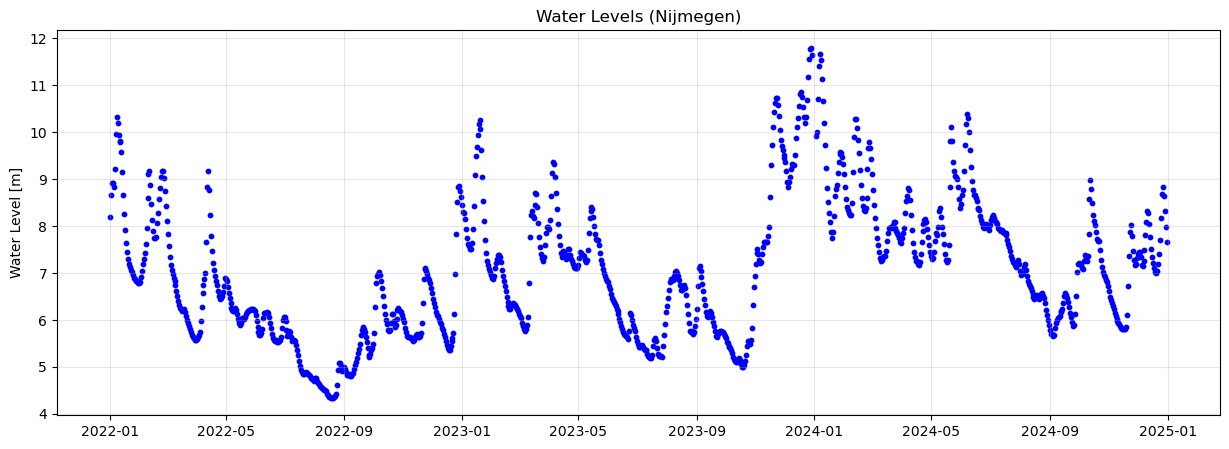

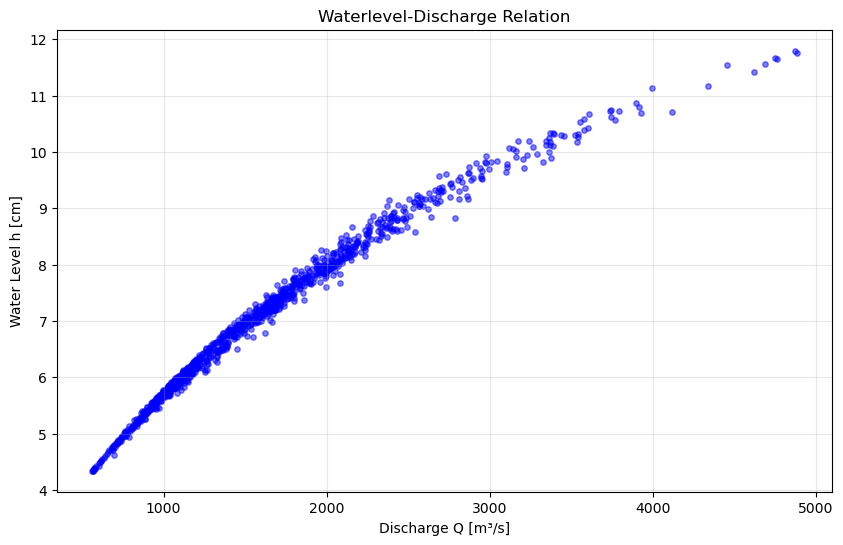

In [4]:
# Split data into training and validation sets.
combined_df = pd.concat([Q_series, h_series], axis=1, join='inner')
combined_df.columns = ['Q_m3s', 'h_meters']

print(f"Total Combined Days: {len(combined_df)}")

Q_data = combined_df['Q_m3s'].values
h_data = combined_df['h_meters'].values

plt.figure(figsize=(15, 5))
plt.scatter(combined_df.index, h_data, s=10, color='blue')
plt.title("Water Levels (Nijmegen)")
plt.ylabel("Water Level [m]")
plt.grid(True, alpha=0.3)

plt.figure(figsize=(10, 6))
plt.scatter(Q_data, h_data, s=15, alpha=0.5, color='blue')
plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water Level h [cm]")
plt.title("Waterlevel-Discharge Relation")
plt.grid(True, alpha=0.3)
plt.show()

## PyMC

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_a, b, h0, log_sigma]


c:\Users\samwi\miniconda3\envs\bayes_env\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 403 seconds.


         mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
a      7.0860  1.1048  5.1980   9.3138     0.0305   0.0184  1273.2069   
b      2.5129  0.0490  2.4208   2.6026     0.0014   0.0008  1270.9495   
h0    -1.4997  0.1718 -1.8118  -1.1734     0.0048   0.0029  1285.0871   
sigma  0.1131  0.0024  0.1087   0.1179     0.0000   0.0000  2881.5652   

        ess_tail   r_hat  
a      1727.4592  1.0022  
b      1764.7385  1.0022  
h0     1679.9711  1.0021  
sigma  2691.3377  1.0016  


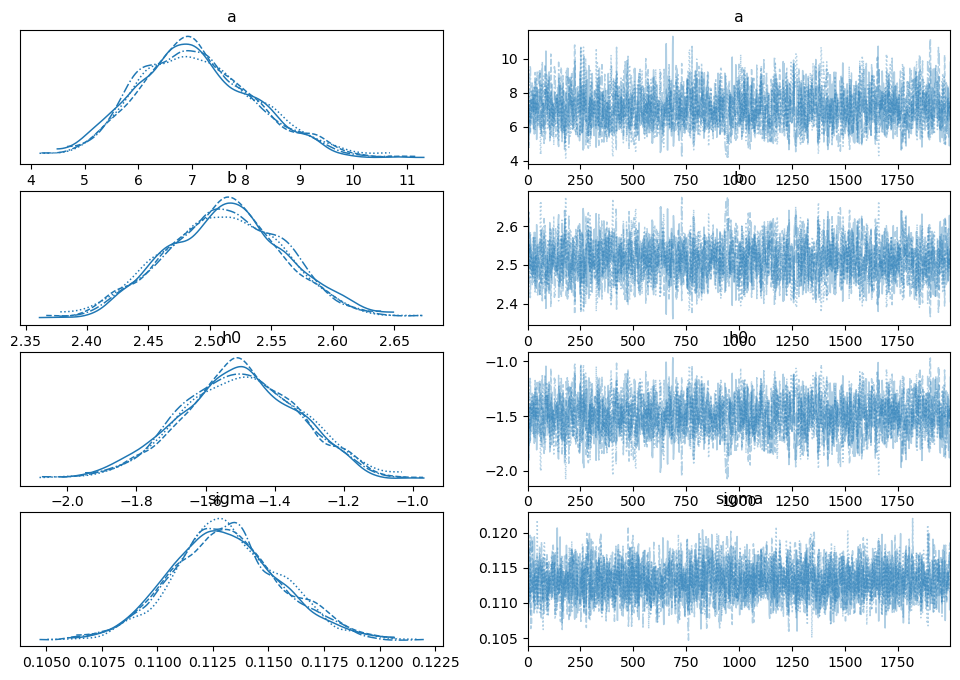

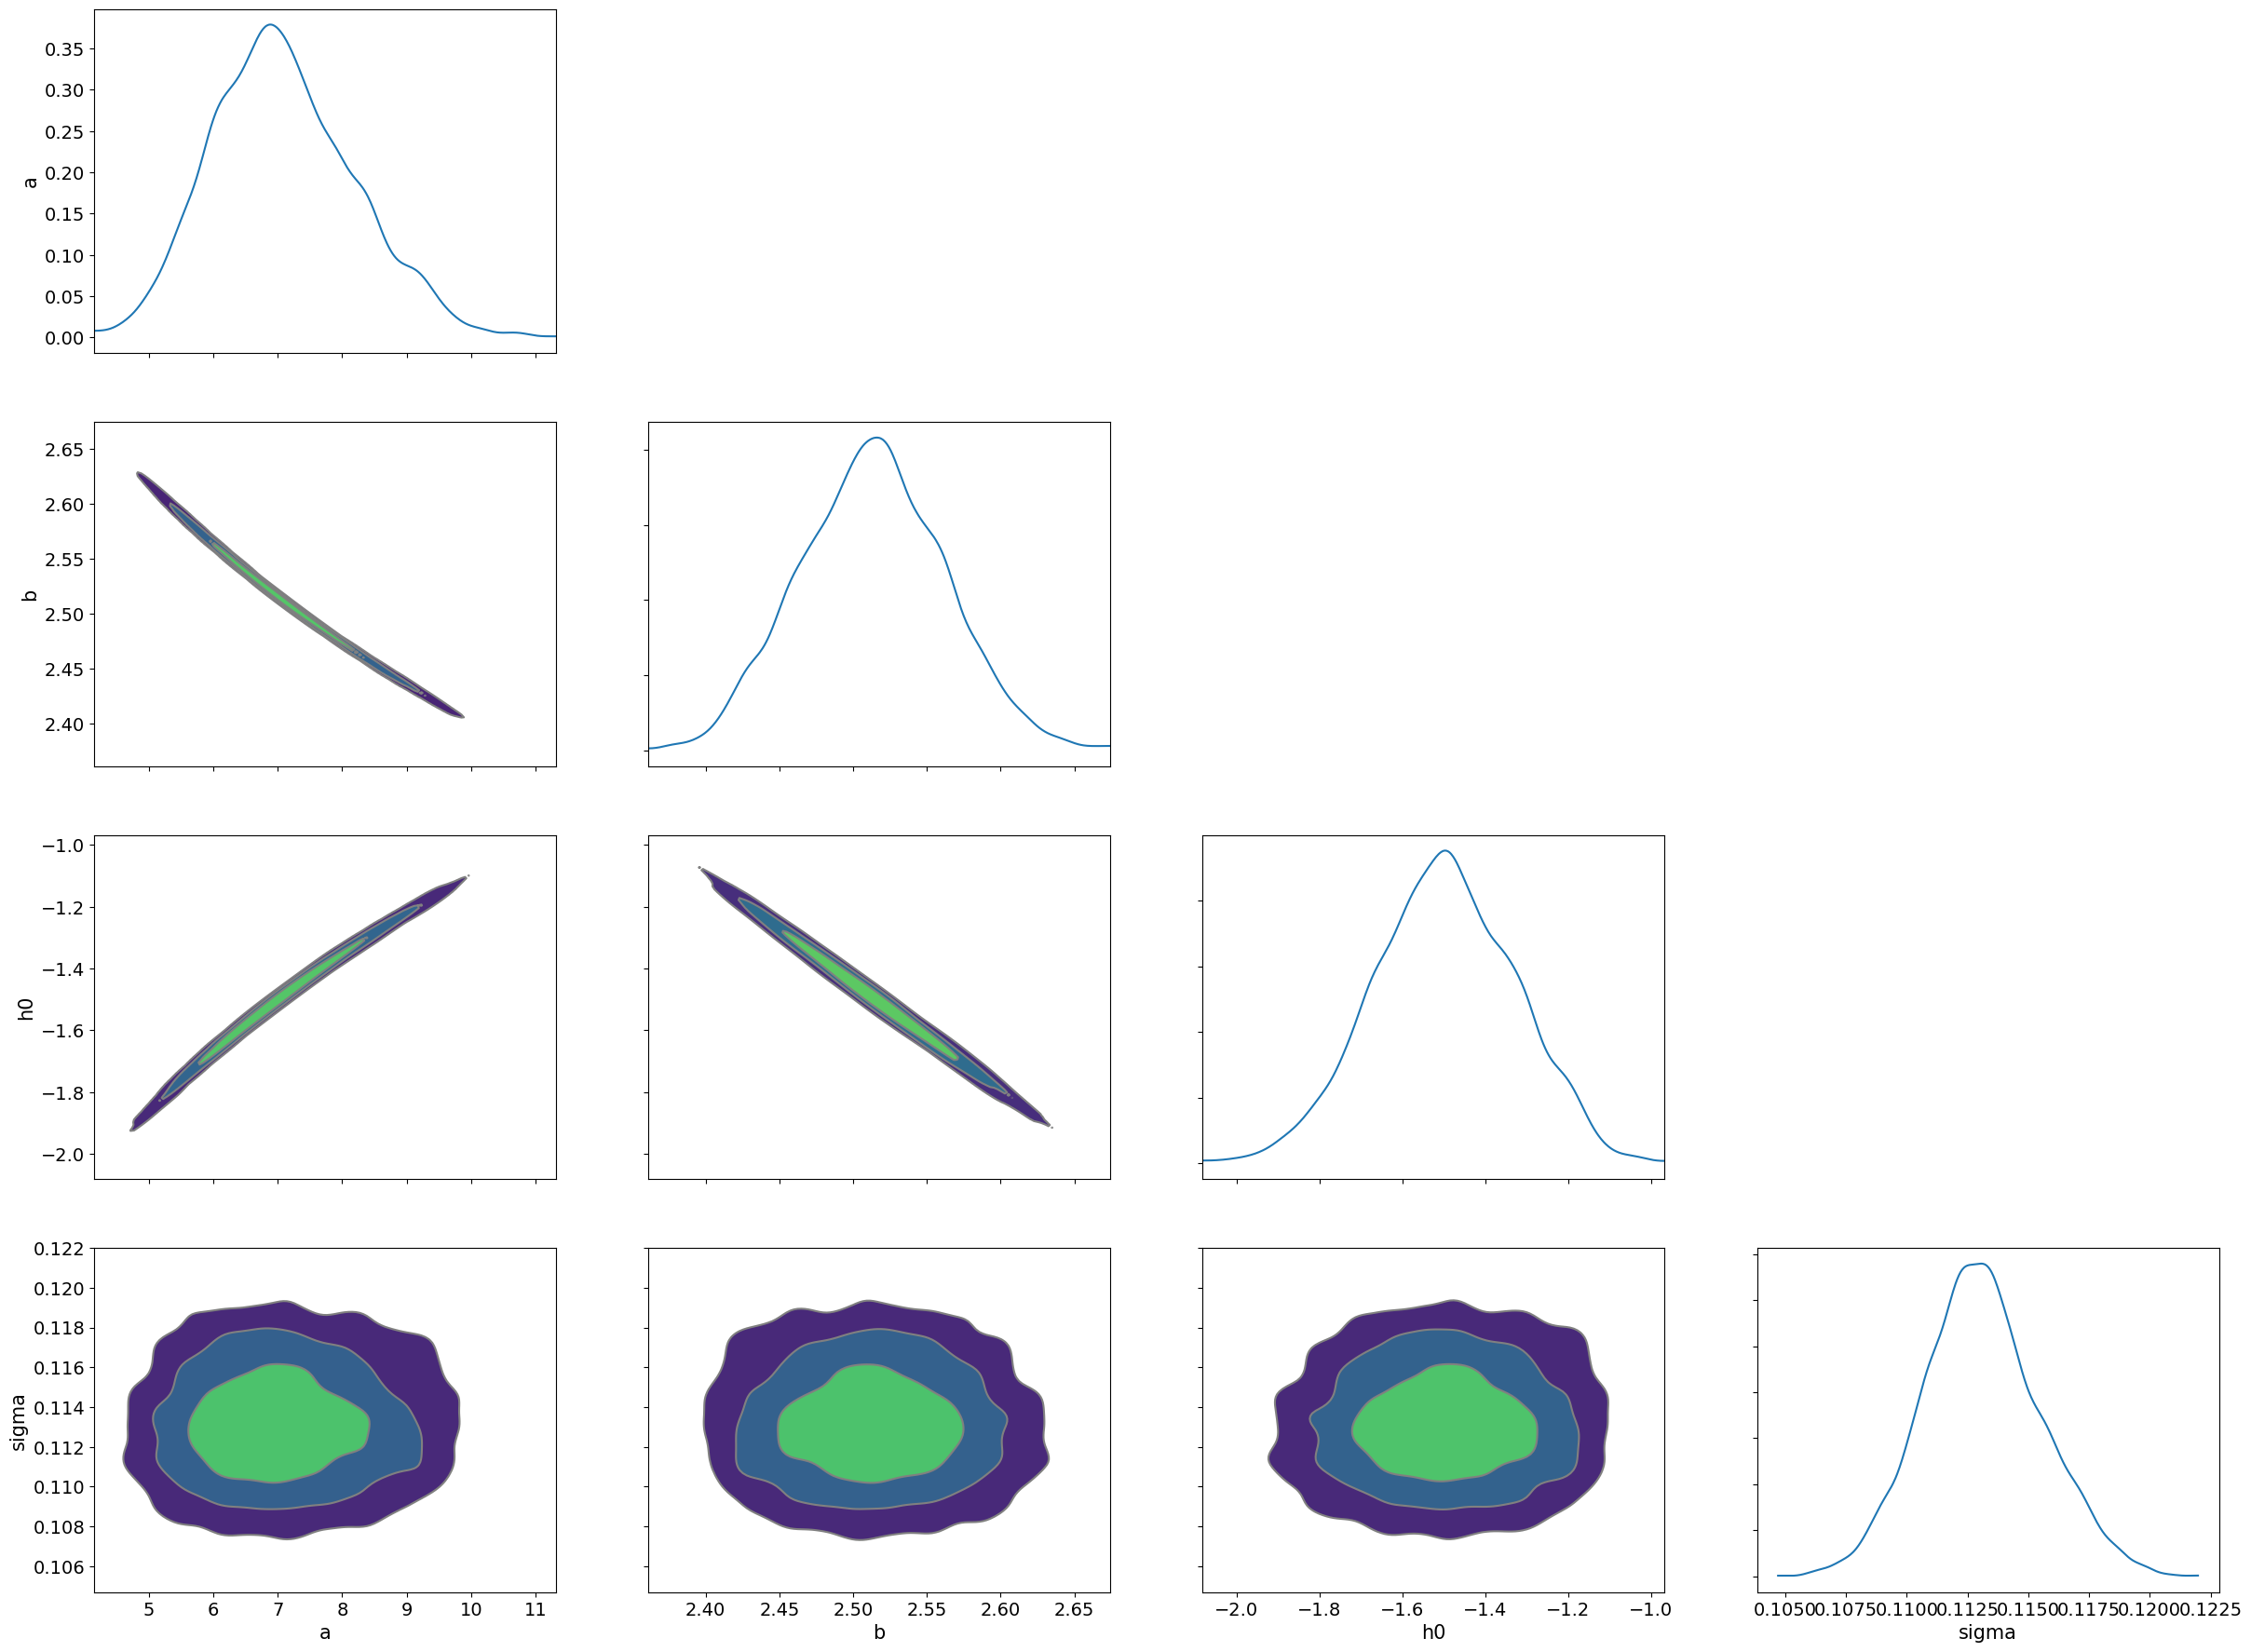

Sampling: [h_obs]


c:\Users\samwi\miniconda3\envs\bayes_env\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

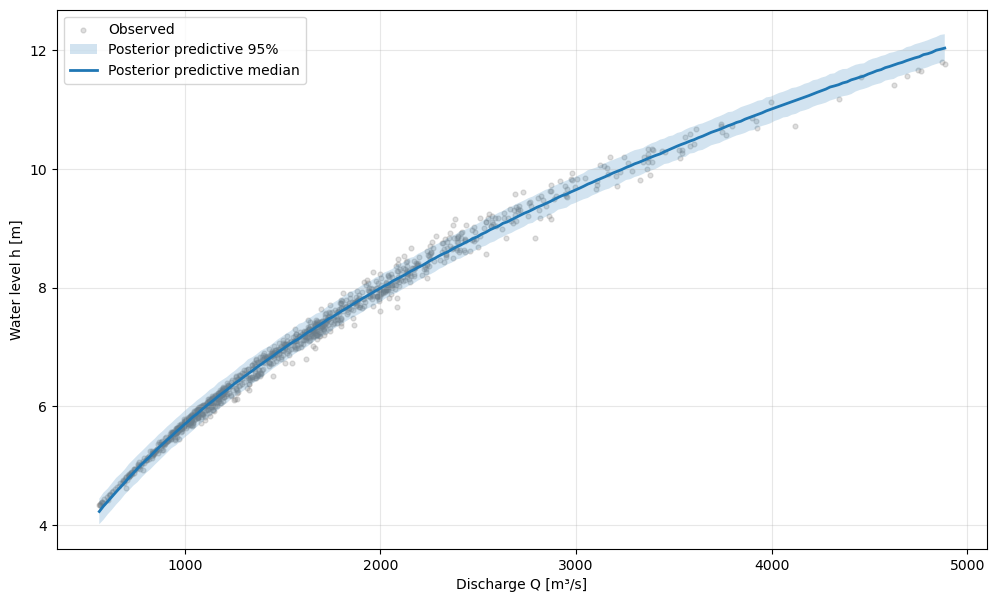

In [ ]:
# --- data ---
Q = Q_data.astype(float)
h = h_data.astype(float)

min_h = float(np.min(h))

# optional: scale Q to improve geometry for NUTS (often helps)
Q_scale = np.median(Q)
Qn = Q / Q_scale

with pm.Model() as model:
    # Priors
    log_a = pm.Normal("log_a", mu=np.log(10.0), sigma=0.5)
    a = pm.Deterministic("a", pm.math.exp(log_a))

    b = pm.LogNormal("b", mu=np.log(2.3), sigma=0.35)  # b>0

    h0 = pm.Normal("h0", mu=-2.0, sigma=1.0)

    log_sigma = pm.Normal("log_sigma", mu=np.log(0.1), sigma=0.7)
    sigma = pm.Deterministic("sigma", pm.math.exp(log_sigma))

    # Model: h = h0 + (Q/a)^(1/b)
    # Using scaled Qn -> adjust 'a' by scaling too:
    # (Q/a) = (Qn*Q_scale)/a = Qn/(a/Q_scale)
    # easiest: define a_scaled = a / Q_scale
    a_scaled = pm.Deterministic("a_scaled", a / Q_scale)

    mu = h0 + (pm.math.maximum(Qn / a_scaled, 0.0)) ** (1.0 / b)

    # Likelihood (Normal). If you have outliers, switch to StudentT below.
    obs = pm.Normal("h_obs", mu=mu, sigma=sigma, observed=h)

    # Sample with NUTS
    idata = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.9,   # raise to 0.95 if you see many divergences
        random_seed=42)

# Diagnostics
print(az.summary(idata, var_names=["a", "b", "h0", "sigma"], round_to=4))
az.plot_trace(idata, var_names=["a", "b", "h0", "sigma"])
plt.show()

az.plot_pair(idata, var_names=["a", "b", "h0", "sigma"], kind="kde", marginals=True)
plt.show()

# Posterior predictive (this includes parameter uncertainty + observation noise)
with model:
    ppc = pm.sample_posterior_predictive(idata, var_names=["h_obs"], random_seed=42)

# Build posterior predictive band over a Q-range
Q_range = np.linspace(Q.min(), Q.max(), 200)
Qn_range = Q_range / Q_scale

# Take posterior draws for parameters
post = idata.posterior
a_s = post["a"].values.reshape(-1)
b_s = post["b"].values.reshape(-1)
h0_s = post["h0"].values.reshape(-1)
sig_s = post["sigma"].values.reshape(-1)

# simulate predictive curves
N = min(2000, a_s.size)
idx = np.random.choice(a_s.size, size=N, replace=False)

pred = np.zeros((N, Q_range.size))
for i, k in enumerate(idx):
    mu_k = h0_s[k] + np.power(np.maximum(Qn_range / (a_s[k] / Q_scale), 0.0), 1.0 / b_s[k])
    pred[i] = mu_k + np.random.normal(0.0, sig_s[k], size=Q_range.size)

lo, med, hi = np.percentile(pred, [2.5, 50, 97.5], axis=0)

plt.figure(figsize=(12, 7))
plt.scatter(Q, h, s=12, alpha=0.25, color="gray", label="Observed")
plt.fill_between(Q_range, lo, hi, alpha=0.2, label="Posterior predictive 95%")
plt.plot(Q_range, med, linewidth=2, label="Posterior predictive median")
plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water level h [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

*Sams poging*

## Functions

### 4. Stage–Discharge Model

In [8]:
def stage_discharge_model(Q, a, b, h0):
    term = np.maximum(Q / a, 0.0)
    return h0 + np.power(term, 1.0 / b)

### 5. Model Formulation

In [ ]:
def unpack(theta):
    log_a, b, h0, log_sigma = theta
    a = np.exp(log_a)
    sigma = np.exp(log_sigma)
    return a, b, h0, sigma

def log_prior(theta, h_data):
    log_a, b, h0, log_sigma = theta
    a, b, h0, sigma = unpack(theta)

    if b <= 0 or not np.isfinite(a) or not np.isfinite(sigma):
        return -np.inf

    min_h = np.min(h_data)
    if h0 > min_h: 
        return -np.inf

    lp  = stats.norm.logpdf(log_a, loc=np.log(10.0), scale=0.3)     
    lp += stats.norm.logpdf(b, loc=2.3, scale=0.5)
    lp += stats.norm.logpdf(h0, loc=-2.0, scale=0.5)
    lp += stats.norm.logpdf(log_sigma, loc=np.log(0.1), scale=0.5)
    return lp

def log_likelihood(theta, Q_data, h_data):
    a, b, h0, sigma = unpack(theta)
    h_model = stage_discharge_model(Q_data, a, b, h0)
    residuals = h_data - h_model
    return np.sum(stats.norm.logpdf(residuals, loc=0.0, scale=sigma))

def log_posterior(theta, Q_data, h_data):
    lp = log_prior(theta, h_data)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, Q_data, h_data)

In [ ]:
def run_mcmc_chain(chain_id, n_iterations, initial_theta, step_sizes, Q_data, h_data):
    chain = np.zeros((n_iterations, 4))
    chain[0] = initial_theta

    cov_prop = np.diag(step_sizes**2)
    current_log_post = log_posterior(initial_theta, Q_data, h_data)

    print(f"Chain {chain_id} start: {np.round(initial_theta, 3)}")

    accepted = 0

    for i in range(1, n_iterations):
        proposal = chain[i-1] + stats.multivariate_normal.rvs(mean=np.zeros(4), cov=cov_prop)
        prop_log_post = log_posterior(proposal, Q_data, h_data)

        log_alpha = prop_log_post - current_log_post
        if np.log(np.random.rand()) < log_alpha:
            chain[i] = proposal
            current_log_post = prop_log_post
            accepted += 1
        else:
            chain[i] = chain[i-1]

    print(f"Chain {chain_id} done")
    # at end of run_mcmc_chain
    acc_rate = accepted / (n_iterations - 1)
    print(f"Chain {chain_id} acc rate: {acc_rate:.3f}")

    return chain

## MCMC configuration

#### Initial values

--- Starting 4 MCMC Chains ---
Chain 1 start: [ 1.874  2.518 -1.542 -2.166]
Chain 1 done
Chain 1 acc rate: 0.017
Chain 2 start: [ 1.939  2.498 -1.412 -2.218]
Chain 2 done
Chain 2 acc rate: 0.018
Chain 3 start: [ 2.002  2.532 -1.461 -2.133]
Chain 3 done
Chain 3 acc rate: 0.018
Chain 4 start: [ 1.93   2.501 -1.419 -2.147]
Chain 4 done
Chain 4 acc rate: 0.018

--- (ArviZ Rank-Normalized) ---
Target: R_hat < 1.05
log_a      : 1.11419  [NOT CONVERGED]
log_b      : 1.11385  [NOT CONVERGED]
h0         : 1.11333  [NOT CONVERGED]
log_sigma  : 1.03623  [CONVERGED]

--- Final Calibrated Parameters (posterior means) ---
a        : 7.3180
b        : 2.5020
h0       : -1.4619
sigma    : 0.1134


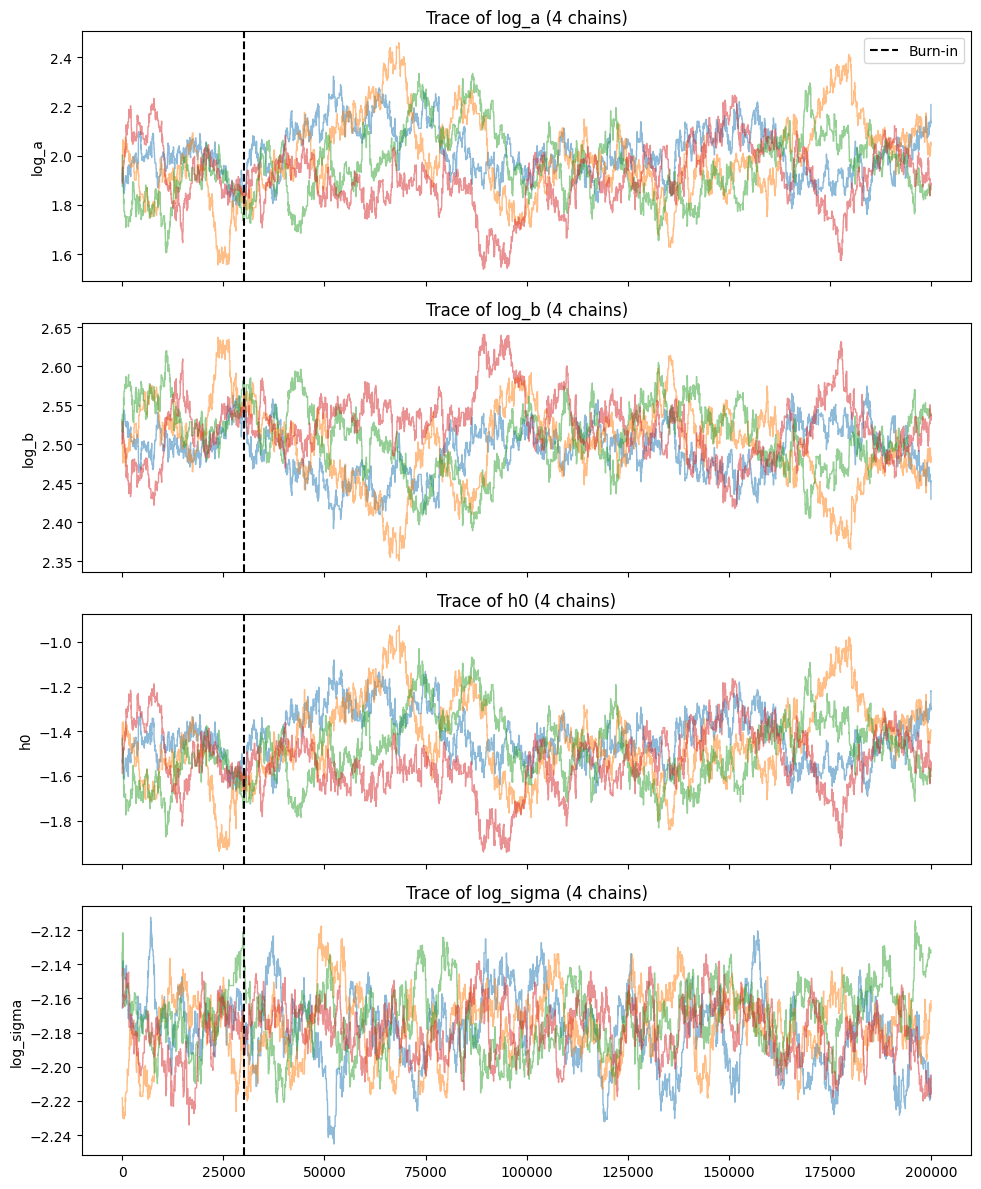

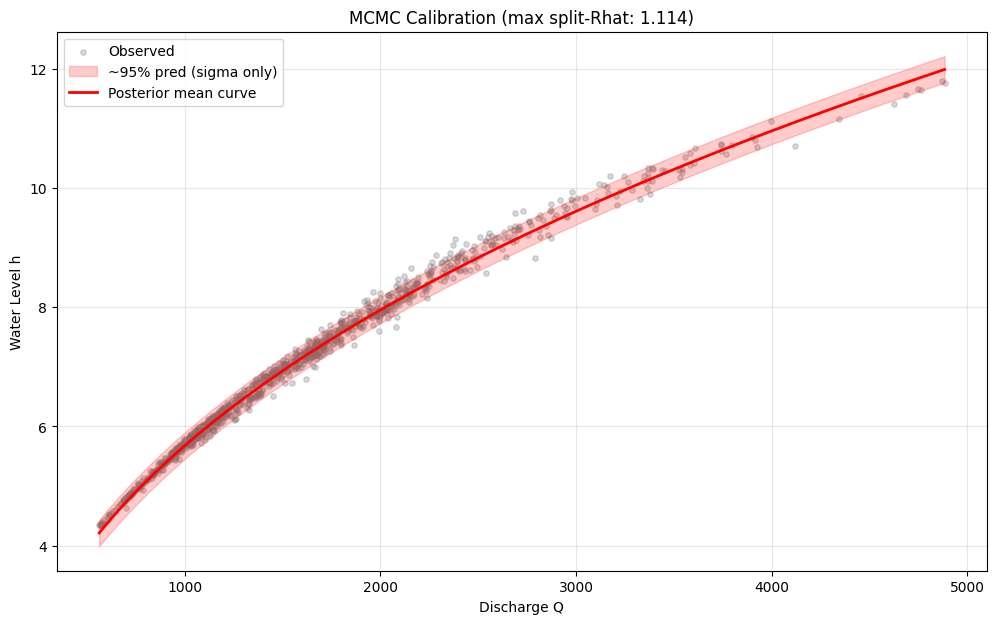

In [ ]:
n_chains     = 4
n_iterations = 200000
burn_in      = 30000

step_sizes = np.array([0.15, 0.05, 0.18, 0.02]) * 0.2

min_h = np.min(h_data)
base_theta = np.array([
    np.log(post["a"].values.mean()),
    post["b"].values.mean(),   
    post["h0"].values.mean(),
    np.log(post["sigma"].values.mean())])

start_scales = np.array([0.05, 0.02, 0.05, 0.05])

all_chains_full = []
all_chains_burn = []

print(f"--- Starting {n_chains} MCMC Chains ---")

for c in range(n_chains):
    noise = np.random.normal(0, 1, 4) * start_scales
    start_theta = base_theta + noise

    start_theta[1] = max(start_theta[1], 1e-3)
    start_theta[2] = min(start_theta[2], min_h - 1e-3)

    chain_c = run_mcmc_chain(chain_id=c+1, n_iterations=n_iterations,
        initial_theta=start_theta, step_sizes=step_sizes,
        Q_data=Q_data, h_data=h_data)

    all_chains_full.append(chain_c)
    all_chains_burn.append(chain_c[burn_in:])

chains_full = np.array(all_chains_full)          
chains_post = chains_full[:, burn_in:, :]        

param_labels = ["log_a", "log_b", "h0", "log_sigma"]

data_dict = {
    name: chains_post[:, :, i] for i, name in enumerate(param_labels)
}

inference_data = az.from_dict(posterior=data_dict)
r_hat_dataset = az.rhat(inference_data, method="rank")
r_hat_values = np.array([float(r_hat_dataset[name]) for name in param_labels])

print("\n--- (ArviZ Rank-Normalized) ---")
print("Target: R_hat < 1.05")
for name, r_val in zip(param_labels, r_hat_values):
    status = "CONVERGED" if r_val < 1.05 else "NOT CONVERGED"
    print(f"{name:10} : {r_val:.5f}  [{status}]")

combined = chains_post.reshape(-1, 4)

log_a_est     = np.mean(combined[:, 0])
b_est     = np.mean(combined[:, 1])
h0_est        = np.mean(combined[:, 2])
log_sigma_est = np.mean(combined[:, 3])

a_samples = np.exp(combined[:, 0])
sigma_samples = np.exp(combined[:, 3])

a_est = a_samples.mean()
sigma_est = sigma_samples.mean()

print("\n--- Final Calibrated Parameters (posterior means) ---")
print(f"a        : {a_est:.4f}")
print(f"b        : {b_est:.4f}")
print(f"h0       : {h0_est:.4f}")
print(f"sigma    : {sigma_est:.4f}")

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for j, ax in enumerate(axes):
    for c in range(n_chains):
        ax.plot(chains_full[c, :, j], color=colors[c], alpha=0.5, linewidth=1)
    ax.axvline(burn_in, color='black', linestyle='--', label='Burn-in')
    ax.set_ylabel(param_labels[j])
    ax.set_title(f"Trace of {param_labels[j]} (4 chains)")
    if j == 0:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
plt.scatter(Q_data, h_data, alpha=0.3, label='Observed', color='gray', s=15)

Q_range = np.linspace(np.min(Q_data), np.max(Q_data), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

upper = h_mean_fit + 1.96 * sigma_est
lower = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower, upper, color='red', alpha=0.2, label='~95% pred (sigma only)')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Posterior mean curve')

plt.xlabel("Discharge Q")
plt.ylabel("Water Level h")
plt.title(f"MCMC Calibration (max split-Rhat: {np.max(r_hat_values):.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### More iterations (n_iterations = 80 000)

In [9]:
n_chains     = 4
n_iterations = 80000
burn_in      = 10000

step_sizes = np.array([0.012, 0.008, 0.012, 0.02])

min_h = np.min(h_data)
base_theta = np.array([np.log(10.0), 2.5, min_h - 0.5, np.log(0.1)])

start_scales = np.array([0.6, 0.6, 0.5, 0.6])  

all_chains_full = []
all_chains_burn = []

print(f"--- Starting {n_chains} MCMC Chains ---")

for c in range(n_chains):
    noise = np.random.normal(0, 1, 4) * start_scales
    start_theta = base_theta + noise

    start_theta[1] = abs(start_theta[1]) + 1e-3
    start_theta[2] = min_h - abs(start_theta[2] - min_h) - 1e-3

    chain_c = run_mcmc_chain(chain_id=c+1, n_iterations=n_iterations,
        initial_theta=start_theta, step_sizes=step_sizes,
        Q_data=Q_data, h_data=h_data)

    all_chains_full.append(chain_c)
    all_chains_burn.append(chain_c[burn_in:])

chains_full = np.array(all_chains_full)          
chains_post = chains_full[:, burn_in:, :]        
r_hat_values = calculate_r_hat(chains_post)

param_labels = ["log_a", "b", "h0", "log_sigma"] 

print("\n--- Gelman-Rubin Convergence Diagnostics ---")
print("Target: R_hat < 1.05")
for name, r_val in zip(param_labels, r_hat_values):
    status = "CONVERGED" if r_val < 1.05 else "NOT CONVERGED"
    print(f"{name:10} : {r_val:.5f}  [{status}]")

combined = chains_post.reshape(-1, 4)

log_a_est     = np.mean(combined[:, 0])
b_est         = np.mean(combined[:, 1])
h0_est        = np.mean(combined[:, 2])
log_sigma_est = np.mean(combined[:, 3])

a_est     = np.exp(log_a_est)
sigma_est = np.mean(np.exp(combined[:, 3])) 

print("\n--- Final Calibrated Parameters (posterior means) ---")
print(f"a        : {a_est:.4f}")
print(f"b        : {b_est:.4f}")
print(f"h0       : {h0_est:.4f}")
print(f"sigma    : {sigma_est:.4f}")

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for j, ax in enumerate(axes):
    for c in range(n_chains):
        ax.plot(chains_full[c, :, j], color=colors[c], alpha=0.5, linewidth=1)
    ax.axvline(burn_in, color='black', linestyle='--', label='Burn-in')
    ax.set_ylabel(param_labels[j])
    ax.set_title(f"Trace of {param_labels[j]} (4 chains)")
    if j == 0:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
plt.scatter(Q_data, h_data, alpha=0.3, label='Observed', color='gray', s=15)

Q_range = np.linspace(np.min(Q_data), np.max(Q_data), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

upper = h_mean_fit + 1.96 * sigma_est
lower = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower, upper, color='red', alpha=0.2, label='~95% pred (sigma only)')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Posterior mean curve')

plt.xlabel("Discharge Q")
plt.ylabel("Water Level h")
plt.title(f"MCMC Calibration (max split-Rhat: {np.max(r_hat_values):.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Starting 4 MCMC Chains ---
Chain 1 start: [ 2.629  2.304  3.842 -1.765]
Chain 1 done
Chain 2 start: [ 2.266  2.469  4.04  -2.561]
Chain 2 done
Chain 3 start: [ 2.007  1.816  3.183 -2.405]
Chain 3 done
Chain 4 start: [ 2.238  2.175  3.461 -1.686]
Chain 4 done


NameError: name 'calculate_r_hat' is not defined

#### Kleinere stapgrootte (werkt niet)

--- Starting 4 MCMC Chains ---
Chain 1 start: [ 2.635  1.231  4.335 -2.931]
Chain 1 done
Chain 2 start: [ 0.887  1.762  3.173 -2.136]
Chain 2 done
Chain 3 start: [ 1.808  2.503  3.219 -2.573]
Chain 3 done
Chain 4 start: [ 2.851  3.776  3.476 -2.558]
Chain 4 done

--- Gelman-Rubin Convergence Diagnostics ---
Target: R_hat < 1.05
log_a      : 1.15714  [NOT CONVERGED]
b          : 1.15747  [NOT CONVERGED]
h0         : 1.15567  [NOT CONVERGED]
log_sigma  : 1.03558  [CONVERGED]

--- Final Calibrated Parameters (posterior means) ---
a        : 14.3184
b        : 2.2848
h0       : -0.6977
sigma    : 0.1147


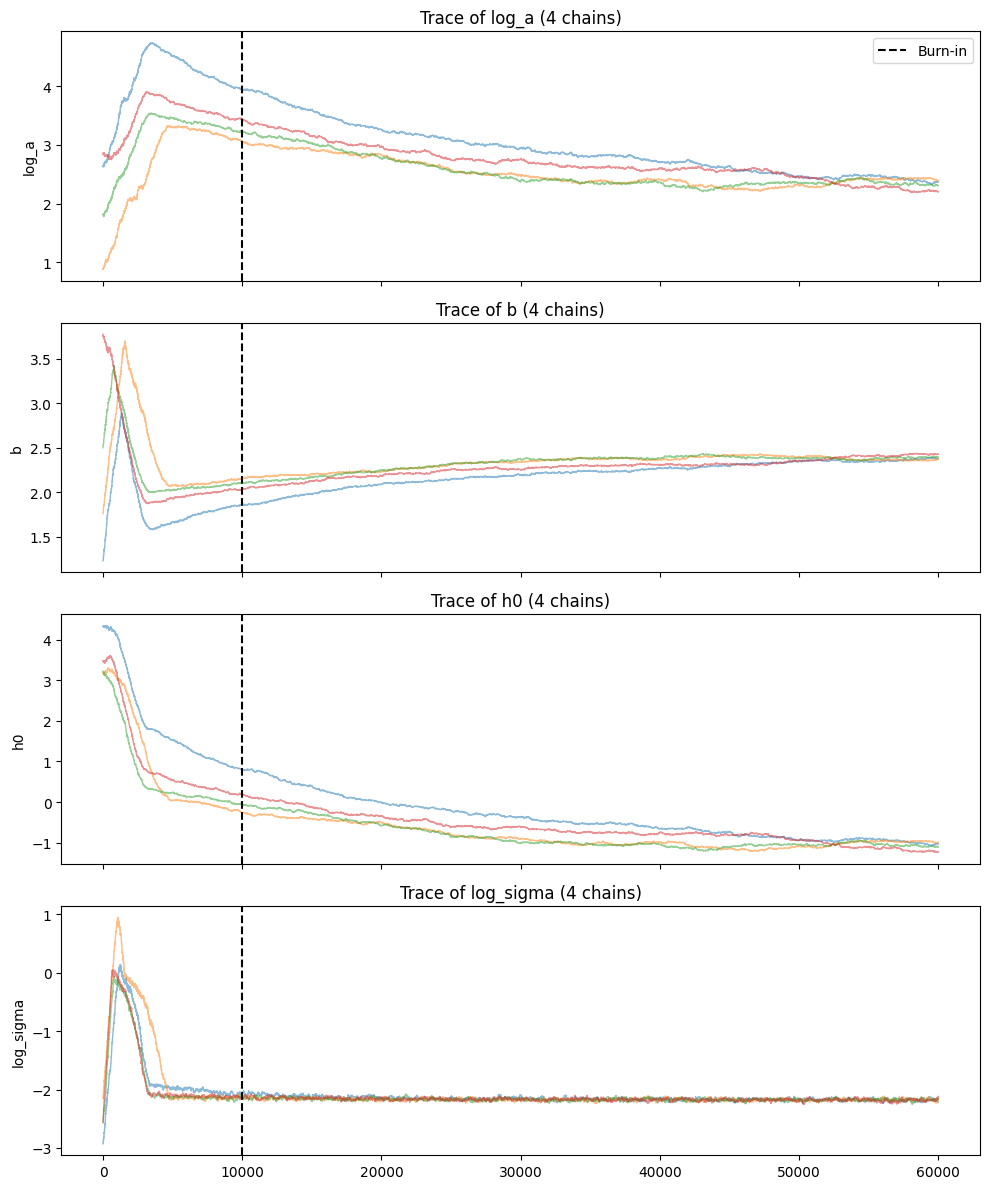

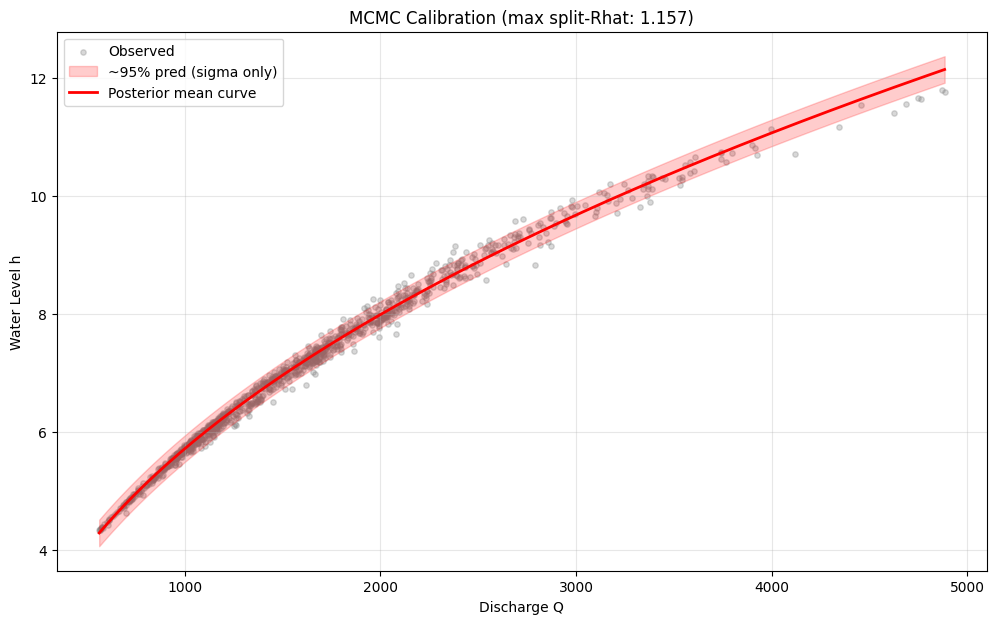

In [ ]:
n_chains     = 4
n_iterations = 60000
burn_in      = 10000

step_sizes = np.array([0.005, 0.005, 0.005, 0.01]) 

min_h = np.min(h_data)
base_theta = np.array([np.log(10.0), 2.5, min_h - 0.5, np.log(0.1)])

start_scales = np.array([0.6, 0.6, 0.5, 0.6])  

all_chains_full = []
all_chains_burn = []

print(f"--- Starting {n_chains} MCMC Chains ---")

for c in range(n_chains):
    noise = np.random.normal(0, 1, 4) * start_scales
    start_theta = base_theta + noise

    start_theta[1] = abs(start_theta[1]) + 1e-3
    start_theta[2] = min_h - abs(start_theta[2] - min_h) - 1e-3

    chain_c = run_mcmc_chain(chain_id=c+1, n_iterations=n_iterations,
        initial_theta=start_theta, step_sizes=step_sizes,
        Q_data=Q_data, h_data=h_data)

    all_chains_full.append(chain_c)
    all_chains_burn.append(chain_c[burn_in:])

chains_full = np.array(all_chains_full)          
chains_post = chains_full[:, burn_in:, :]        
r_hat_values = calculate_r_hat(chains_post)

param_labels = ["log_a", "b", "h0", "log_sigma"] 

print("\n--- Gelman-Rubin Convergence Diagnostics ---")
print("Target: R_hat < 1.05")
for name, r_val in zip(param_labels, r_hat_values):
    status = "CONVERGED" if r_val < 1.05 else "NOT CONVERGED"
    print(f"{name:10} : {r_val:.5f}  [{status}]")

combined = chains_post.reshape(-1, 4)

log_a_est     = np.mean(combined[:, 0])
b_est         = np.mean(combined[:, 1])
h0_est        = np.mean(combined[:, 2])
log_sigma_est = np.mean(combined[:, 3])

a_est     = np.exp(log_a_est)
sigma_est = np.mean(np.exp(combined[:, 3])) 

print("\n--- Final Calibrated Parameters (posterior means) ---")
print(f"a        : {a_est:.4f}")
print(f"b        : {b_est:.4f}")
print(f"h0       : {h0_est:.4f}")
print(f"sigma    : {sigma_est:.4f}")

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for j, ax in enumerate(axes):
    for c in range(n_chains):
        ax.plot(chains_full[c, :, j], color=colors[c], alpha=0.5, linewidth=1)
    ax.axvline(burn_in, color='black', linestyle='--', label='Burn-in')
    ax.set_ylabel(param_labels[j])
    ax.set_title(f"Trace of {param_labels[j]} (4 chains)")
    if j == 0:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
plt.scatter(Q_data, h_data, alpha=0.3, label='Observed', color='gray', s=15)

Q_range = np.linspace(np.min(Q_data), np.max(Q_data), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

upper = h_mean_fit + 1.96 * sigma_est
lower = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower, upper, color='red', alpha=0.2, label='~95% pred (sigma only)')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Posterior mean curve')

plt.xlabel("Discharge Q")
plt.ylabel("Water Level h")
plt.title(f"MCMC Calibration (max split-Rhat: {np.max(r_hat_values):.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Verhoogde burn-in (werkt niet)

--- Starting 4 MCMC Chains ---
Chain 1 start: [ 2.96   3.005  3.247 -1.44 ]
Chain 1 done
Chain 2 start: [ 2.228  2.156  4.143 -1.083]
Chain 2 done
Chain 3 start: [ 2.964  2.137  3.746 -1.222]
Chain 3 done
Chain 4 start: [ 1.838  3.998  3.375 -2.713]
Chain 4 done

--- Gelman-Rubin Convergence Diagnostics ---
Target: R_hat < 1.05
log_a      : 1.27791  [NOT CONVERGED]
b          : 1.27567  [NOT CONVERGED]
h0         : 1.27613  [NOT CONVERGED]
log_sigma  : 1.00119  [CONVERGED]

--- Final Calibrated Parameters (posterior means) ---
a        : 8.8605
b        : 2.4388
h0       : -1.2384
sigma    : 0.1134


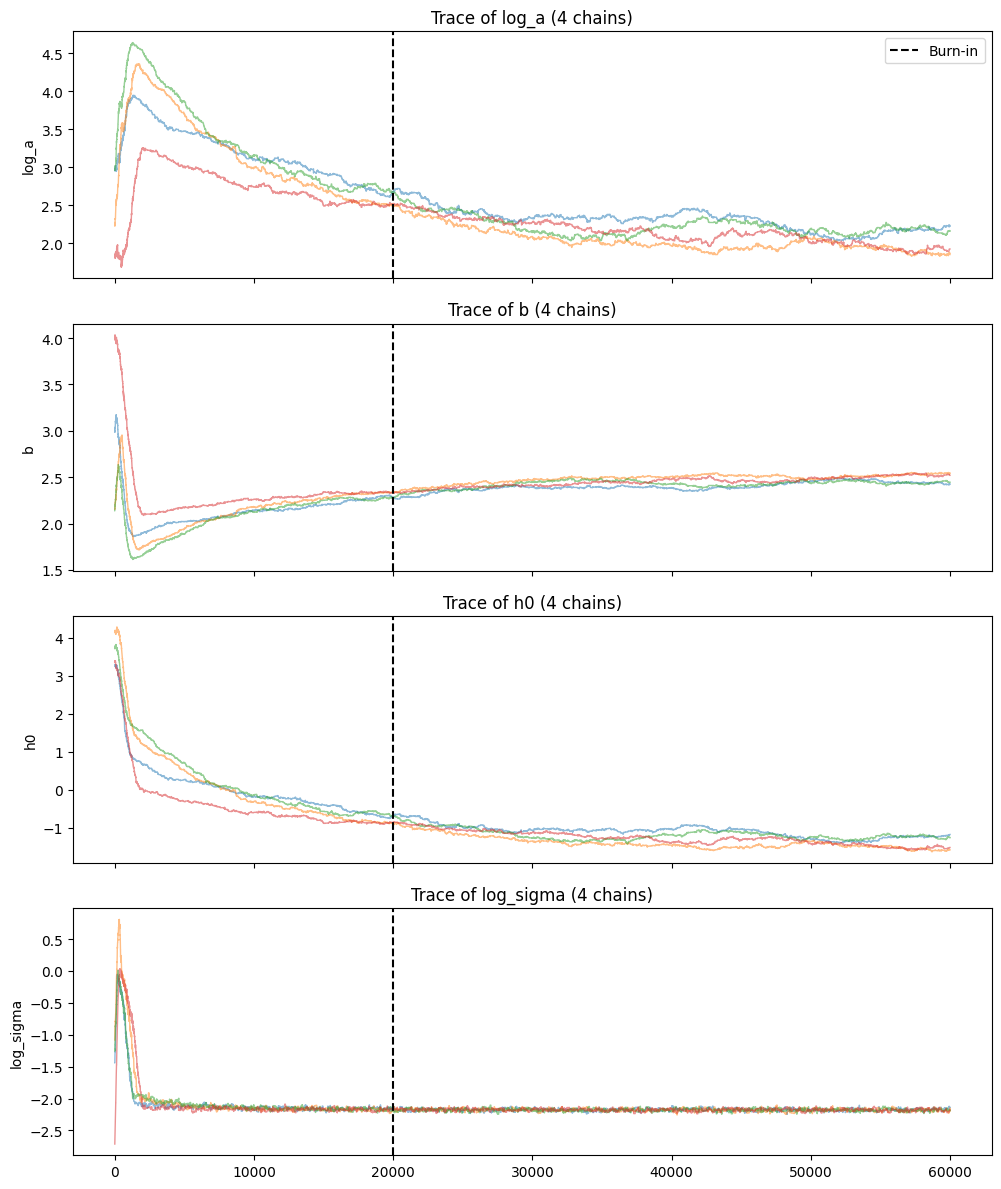

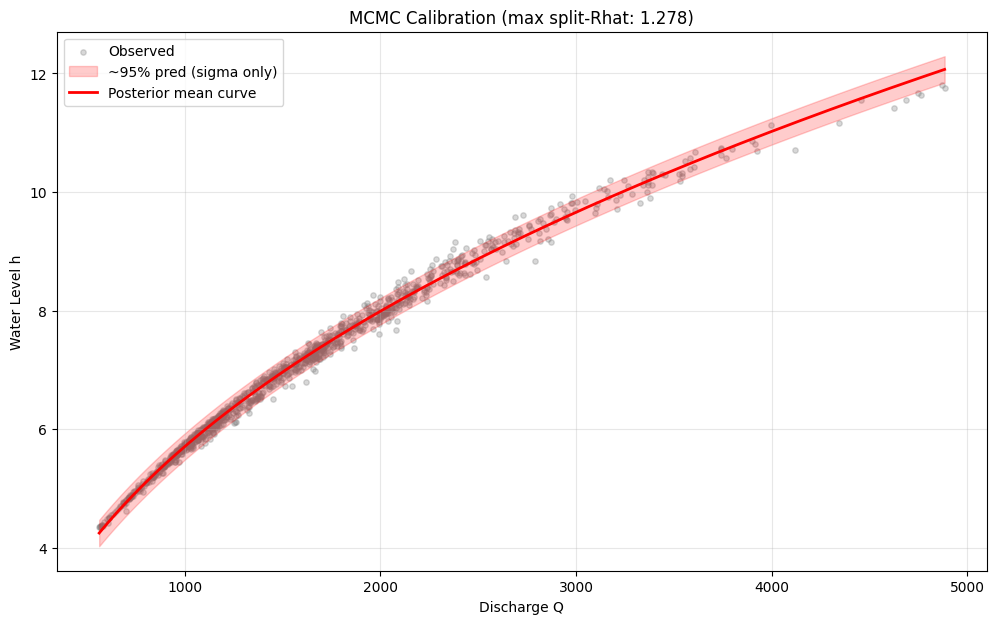

In [ ]:
n_chains     = 4
n_iterations = 60000
burn_in      = 20000

step_sizes = np.array([0.012, 0.008, 0.012, 0.02])

min_h = np.min(h_data)
base_theta = np.array([np.log(10.0), 2.5, min_h - 0.5, np.log(0.1)])

start_scales = np.array([0.6, 0.6, 0.5, 0.6])  

all_chains_full = []
all_chains_burn = []

print(f"--- Starting {n_chains} MCMC Chains ---")

for c in range(n_chains):
    noise = np.random.normal(0, 1, 4) * start_scales
    start_theta = base_theta + noise

    start_theta[1] = abs(start_theta[1]) + 1e-3
    start_theta[2] = min_h - abs(start_theta[2] - min_h) - 1e-3

    chain_c = run_mcmc_chain(chain_id=c+1, n_iterations=n_iterations,
        initial_theta=start_theta, step_sizes=step_sizes,
        Q_data=Q_data, h_data=h_data)

    all_chains_full.append(chain_c)
    all_chains_burn.append(chain_c[burn_in:])

chains_full = np.array(all_chains_full)          
chains_post = chains_full[:, burn_in:, :]        
r_hat_values = calculate_r_hat(chains_post)

param_labels = ["log_a", "b", "h0", "log_sigma"] 

print("\n--- Gelman-Rubin Convergence Diagnostics ---")
print("Target: R_hat < 1.05")
for name, r_val in zip(param_labels, r_hat_values):
    status = "CONVERGED" if r_val < 1.05 else "NOT CONVERGED"
    print(f"{name:10} : {r_val:.5f}  [{status}]")

combined = chains_post.reshape(-1, 4)

log_a_est     = np.mean(combined[:, 0])
b_est         = np.mean(combined[:, 1])
h0_est        = np.mean(combined[:, 2])
log_sigma_est = np.mean(combined[:, 3])

a_est     = np.exp(log_a_est)
sigma_est = np.mean(np.exp(combined[:, 3])) 

print("\n--- Final Calibrated Parameters (posterior means) ---")
print(f"a        : {a_est:.4f}")
print(f"b        : {b_est:.4f}")
print(f"h0       : {h0_est:.4f}")
print(f"sigma    : {sigma_est:.4f}")

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for j, ax in enumerate(axes):
    for c in range(n_chains):
        ax.plot(chains_full[c, :, j], color=colors[c], alpha=0.5, linewidth=1)
    ax.axvline(burn_in, color='black', linestyle='--', label='Burn-in')
    ax.set_ylabel(param_labels[j])
    ax.set_title(f"Trace of {param_labels[j]} (4 chains)")
    if j == 0:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
plt.scatter(Q_data, h_data, alpha=0.3, label='Observed', color='gray', s=15)

Q_range = np.linspace(np.min(Q_data), np.max(Q_data), 200)
h_mean_fit = stage_discharge_model(Q_range, a_est, b_est, h0_est)

upper = h_mean_fit + 1.96 * sigma_est
lower = h_mean_fit - 1.96 * sigma_est

plt.fill_between(Q_range, lower, upper, color='red', alpha=0.2, label='~95% pred (sigma only)')
plt.plot(Q_range, h_mean_fit, color='red', linewidth=2, label='Posterior mean curve')

plt.xlabel("Discharge Q")
plt.ylabel("Water Level h")
plt.title(f"MCMC Calibration (max split-Rhat: {np.max(r_hat_values):.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()